# KNN
<img src='https://i.imgur.com/E7HrgBu.jpeg' width=600>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

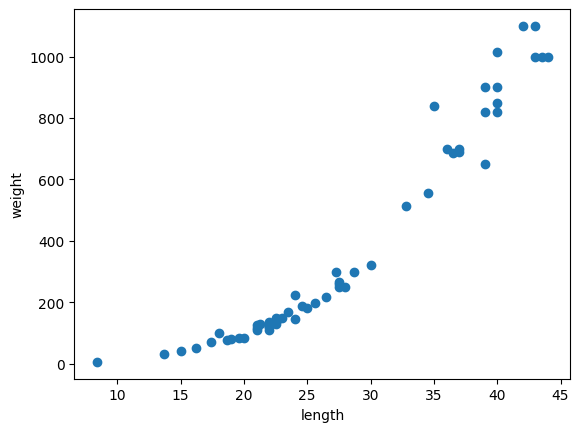

In [3]:
# 산점도
plt.scatter(perch_length, perch_weight, label='data')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [4]:
np.min(perch_weight), np.max(perch_weight)

(np.float64(5.9), np.float64(1100.0))

In [5]:
np.min(perch_length), np.max(perch_length)

(np.float64(8.4), np.float64(44.0))

In [6]:
# 훈련 세트와 테스트 세트로 나누기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(perch_length, perch_weight, test_size=.25, random_state=50)

print(X_train.shape, X_test.shape)

(42,) (14,)


In [7]:
# 배열 변환
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)
print(X_train.shape, X_test.shape)

(42, 1) (14, 1)


### 학습 평가

In [8]:
from sklearn.neighbors import KNeighborsRegressor # k-최근접 이웃 회귀 알고리즘
knn = KNeighborsRegressor()

# k-최근접 이웃 회귀 모델을 훈련합니다.
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
from sklearn.metrics import accuracy_score
pred = knn.predict(X_test)
# accuracy_score(pred, y_test) # why?
knn.score(X_test, y_test)

0.960708316746975

In [10]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score # 타깃과 예측의 절댓값 오차를 평균하여 변환

# 테스트 세트에 대한 예측을 만든다.
# 테스트 세트에 대한 평균 절댓값 오차를 계산
print('MAE ', mean_absolute_error(y_test, pred))
print('MAE ', mean_squared_error(y_test, pred))
print('MAE ', r2_score(y_test, pred))

MAE  53.49285714285715
MAE  4859.197857142858
MAE  0.960708316746975


### 정규화 사용

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_scaled = scaler.fit_transform(X_train)
test_scaled = scaler.fit_transform(X_test)

In [12]:
train_scaled[:5]

array([[-0.56206728],
       [ 1.92103817],
       [ 0.13089238],
       [-0.67756056],
       [-0.38882737]])

In [13]:
knn2 = KNeighborsRegressor()
knn2.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
knn2.score(X_test, y_test)

0.960708316746975

In [15]:
pred_test = knn2.predict(test_scaled)

In [16]:
print('MAE ', mean_absolute_error(y_test, pred_test))
print('MSE ', mean_squared_error(y_test, pred_test))
print('R2 ', r2_score(y_test, pred_test))

MAE  466.3742857142858
MSE  338322.06754285714
R2  -1.7356868162636894


### overfitting vs underfitting

In [17]:
# 과대적합 vs 과소적합
knn.n_neighbors = 3

# 모델을 다시 훈련시킵니다.
knn.fit(X_train, y_train)

print("훈련 세트 정확도:", knn.score(X_train, y_train))
print("테스트 세트 정확도:",knn.score(X_test, y_test))

훈련 세트 정확도: 0.9873032635096736
테스트 세트 정확도: 0.9475225911048493


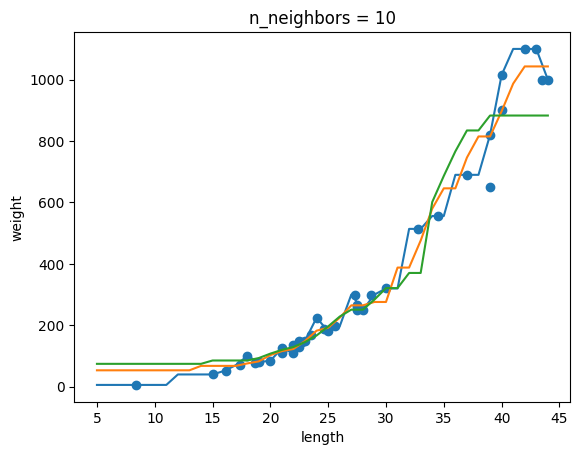

In [18]:
knr = KNeighborsRegressor()
x = np.arange(5,45).reshape(-1,1)

# n = 1,5,10일 때 예측 결과를 그래프로 그립니다
for n in [1,5,10]:
  knr.n_neighbors = n
  knr.fit(X_train, y_train)
  # 지정한 범위 x에 대한 예측을 구합니다.
  pred = knr.predict(x)
  plt.plot(x, pred)

plt.scatter(X_train, y_train)
plt.title('n_neighbors = {}'.format(n))
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [19]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler1 = MinMaxScaler()
scaler2 = StandardScaler()

In [20]:
# train , test scaling


In [22]:
knr2 = KNeighborsRegressor()

# 모델을 다시 훈련시킵니다.
knr2.n_neighbors = 5
# 
# print("훈련 세트 정확도:", knr2.score(train_scaled, train_target))
# print("테스트 세트 정확도:",knr2.score(test_scaled, test_target))

# KNN 분류

In [23]:
from sklearn.datasets import load_wine

wine = load_wine()
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [24]:
# wine 데이터의 feature, target로 Dataframe을 만든다.
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
# df_wine.info() # 빈값이 있는지 검토
# df_wine.isna().sum()

# feature 만 있는 데이터 프레임에 타겟 데이터를 추가한다.
labels = [wine['target_names'][i] for i in wine.target]
labels[:5]

[np.str_('class_0'),
 np.str_('class_0'),
 np.str_('class_0'),
 np.str_('class_0'),
 np.str_('class_0')]

In [25]:
wine.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [26]:
wine['target_names']

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [27]:
# target에 class 이름 매핑 
df_wine['target'] = labels

In [28]:
# class 필드
df_wine['class'] = labels
df_wine.head(3)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0,class_0


In [29]:
# 학습용, 라벨
X = df_wine.drop(['target','class'], axis=1)
y = wine.target

In [30]:
# class 별 개수

df_wine['target'].value_counts()

target
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

In [31]:
df_wine['target'].value_counts() / df_wine['target'].size

target
class_1    0.398876
class_0    0.331461
class_2    0.269663
Name: count, dtype: float64

In [32]:
# 정규화 수행
scaler2 = StandardScaler()
X_std = scaler2.fit_transform(X)
# 데이터세트에서 훈련데이터와 타겟데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=.3, random_state=50)
X_train.shape, y_train.shape

((124, 13), (124,))

In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [34]:
print(knn3.score(X_train, y_train))
print(knn3.score(X_test, y_test))

0.9596774193548387
0.9629629629629629


In [35]:
pred = knn3.predict(X_test)

In [36]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      0.91      0.95        23
           2       0.94      1.00      0.97        15

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



# SVM

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib.pylab as plt
import matplotlib.font_manager as fm
%matplotlib inline

# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac (AppleGothic 또는 AppleSDGothicNeo)
plt.rcParams['font.family'] = 'NanumGothic' # Linux (NanumGothic 또는 다른 설치된 한글 폰트)

plt.rcParams['axes.unicode_minus'] = False #glypy 8722: Axes에 - 표시 안되는 것
# plt.title('한글 타이틀...')

In [38]:
# scikit 의 load_wine
from sklearn.datasets import load_wine
wine = load_wine()
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [39]:
# wine 데이터의 feature, target로 Dataframe을 만든다.
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

# feature 만 있는 데이터 프레임에 타겟 데이터를 추가한다.
df_wine.target = wine.target

C:\Users\USER\AppData\Local\Temp\ipykernel_4900\4235421497.py:5: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_wine.target = wine.target


In [40]:
# target에 class 이름 매핑 
labels = [ wine.target_names[i] for i in wine.target]
df_wine['target'] = labels

In [41]:
# class 필드
df_wine['class'] = labels
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0,class_0


In [42]:
df_wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [43]:
# class 별 개수
print(df_wine['class'].value_counts())
print(df_wine['class'].value_counts()/df_wine.size)

class
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64
class
class_1    0.026592
class_0    0.022097
class_2    0.017978
Name: count, dtype: float64


In [44]:
df_wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0,class_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,class_2,class_2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,class_2,class_2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,class_2,class_2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,class_2,class_2


In [45]:
# 데이터세트에서 훈련데이터와 타겟데이터 분리 
X = df_wine.drop(['target','class'], axis=1)
y = df_wine.target
X.shape, y.shape

((178, 13), (178,))

In [46]:
# 학습 데이터 분리 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.33, random_state=50)
X_train.shape, y_train.shape

((119, 13), (119,))

In [47]:
# svm 모듈
from sklearn.metrics import accuracy_score, classification_report
from sklearn import svm
svc = svm.SVC()

# SVC 학습
svc.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [48]:
# X_test 예측
pred = svc.predict(X_test)

In [49]:
# X_test 의 평가 점수 Result
from sklearn.metrics import accuracy_score, classification_report

print("정답률: ", svc.score(X_test, y_test)) # 동일
print("정답률2: ", accuracy_score(y_test, pred)) # 동일

print('MAE: ', mean_absolute_error(y_test, pred))
print('MSE: ', mean_squared_error(y_test, pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, pred)))

print('R2: ',r2_score(y_test, pred))
print("리포트 = \n", classification_report(y_test, pred))

정답률:  0.6440677966101694
정답률2:  0.6440677966101694
MAE:  0.3559322033898305
MSE:  0.3559322033898305
RMSE:  0.5966005392134929
R2:  0.36330935251798546
리포트 = 
               precision    recall  f1-score   support

           0       0.93      0.81      0.87        16
           1       0.56      0.96      0.70        26
           2       0.00      0.00      0.00        17

    accuracy                           0.64        59
   macro avg       0.49      0.59      0.52        59
weighted avg       0.50      0.64      0.55        59



c:\Users\USER\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 정규화 후 학습

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [51]:
# 훈련데이터, 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=.33, random_state=50)
X_train.shape, X_test.shape

((119, 13), (59, 13))

In [52]:
# 예측
svc1 = svm.SVC()
svc1.fit(X_train, y_train)

pred = svc1.predict(X_test)

# Result
print("정답률: ", svc1.score(X_test, y_test)) # 동일
print("정답률2: ", accuracy_score(y_test, pred)) # 동일

print('MAE: ', mean_absolute_error(y_test, pred))
print('MSE: ', mean_squared_error(y_test, pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, pred)))

print('R2: ', r2_score(y_test, pred))
print("리포트 = \n", classification_report(y_test, pred))

정답률:  0.9830508474576272
정답률2:  0.9830508474576272
MAE:  0.01694915254237288
MSE:  0.01694915254237288
RMSE:  0.13018891098082386
R2:  0.9696813977389517
리포트 = 
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.96      1.00      0.98        26
           2       1.00      1.00      1.00        17

    accuracy                           0.98        59
   macro avg       0.99      0.98      0.98        59
weighted avg       0.98      0.98      0.98        59



### BMI 학습하기

# 키,몸무데,bmi 데이터

In [53]:
tbl = pd.read_csv('./d/bmi20000.csv')
tbl.head()

,height,weight,label
0,125,43,normal
1,121,60,normal
2,183,57,thin
3,135,78,normal
4,162,37,thin


In [54]:
# 학습데이터와 라벨
X = tbl[['height', 'weight']]
# y = tbl.label.apply(lambda x : 0 if x == 'thin' else 1 if x =='normal' else 2)
y = tbl.label

In [ ]:
# # 이 부분도 들어가야 함. 물론 직접 처리해도 무방함
# from sklearn.preprocessing import LabelEncoder

# encoder = LabelEncoder()
# labels = encoder.fit_transform(y)
# labels.shape

(20000,)

In [59]:
%%time

# 학습 데이터와 테스트 데이터로 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42)

# 학습하기
svc2 = svm.SVC()
svc2.fit(X_train, y_train)

CPU times: total: 656 ms
Wall time: 656 ms


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [60]:
#예측하기
pred = svc2.predict(X_test)

#결과
print(accuracy_score(y_test, pred))
# print(mean_absolute_error(y_test, pred))
# print(mean_squared_error(y_test, pred))

0.9911666666666666


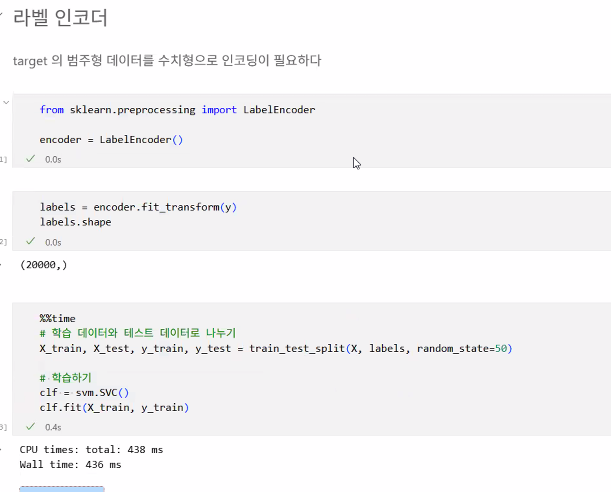

### 표준화로 처리

In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
scaler = StandardScaler()
encoder = LabelEncoder()
X = tbl[['height', 'weight']]
y = tbl.label
y = encoder.fit_transform(y)
X_std = scaler.fit_transform(X)

In [75]:
# 훈련데이터, 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=.3, random_state=42)

# 학습하기
clf = svm.SVC()
clf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [76]:
# 예측
pred = clf.predict(X_test)

In [77]:
from sklearn.metrics import accuracy_score, classification_report

# Result
print("정답률: ", clf.score(X_test, y_test)) # 동일
print("정답률2: ", accuracy_score(y_test, pred)) # 동일

print('MAE: ', mean_absolute_error(y_test, pred))
print('MSE: ', mean_squared_error(y_test, pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, pred)))

print('R2: ', r2_score(y_test, pred))
print("리포트 = \n", classification_report(y_test, pred))

정답률:  0.9931666666666666
정답률2:  0.9931666666666666
MAE:  0.011833333333333333
MSE:  0.021833333333333333
RMSE:  0.14776106839534334
R2:  0.9640082187644571
리포트 = 
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1719
           1       1.00      1.00      1.00      2353
           2       0.99      0.99      0.99      1928

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



### Max 값 정규화

In [ ]:
#칼럼 자르고 정규화 하기
W = tbl.weight / 100  #최대 100kg이라고 가정
H = tbl.height / 200  #최고 200cm라고 가정
W[:3], H[:3]

(0    0.43
 1    0.60
 2    0.57
 Name: weight, dtype: float64,
 0    0.625
 1    0.605
 2    0.915
 Name: height, dtype: float64)

In [79]:
# X = pd.concat([W,H], axis=1)
# X.head()

# SVM의 종류

In [83]:
%%time
from sklearn.svm import LinearSVC

# 학습 데이터와 테스트 데이터로 나누기
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=.33, random_state=50)

# 학습하기
clf = LinearSVC()
clf.fit(X_train, y_train)

#예측하기
pred = clf.predict(X_test)

#결과
print(accuracy_score(y_test, pred))
print(classification_report(pred, y_test))

0.9524242424242424
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1655
           1       1.00      0.94      0.97      2749
           2       1.00      0.94      0.97      2196

    accuracy                           0.95      6600
   macro avg       0.95      0.96      0.95      6600
weighted avg       0.96      0.95      0.95      6600

CPU times: total: 46.9 ms
Wall time: 49.3 ms


In [88]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
df = pd.DataFrame(cancer['data'], columns=cancer.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [90]:
cancer.target, cancer.target_names

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
        0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
        1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
        0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
        1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
        1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [92]:
df['target'] = cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
pd.options.display.max_columns = 50 # 최대 컬럼 수 : 기본은 20

In [98]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
# class 에 target_name 할당
labels = [cancer.target_names[i] for i in cancer.target]
df['class'] = labels
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


<<---- EDA 위한 준비 끝

In [100]:
# 학습 데이터, 라벨 분할
X = df.drop(['target','class'], axis=1)
y = df.target

In [ ]:
# 훈련데이터, 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.33, random_state=50)

In [ ]:
%%time
# %%time은 주피터 노트북에서 제공하는 매직 커맨드
# 학습하기
clf_svm = svm.SVC(kernel='linear') # default: rbf -> 커널변경 ( kernel='linear' 입력 가능)
clf_svm.fit(X_train, y_train)

CPU times: total: 484 ms
Wall time: 479 ms


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [112]:
# X_test 예측
pred = clf_svm.predict(X_test)

In [113]:
# Result
# ac_score = accuracy_score(pred, y_test)
# cl_report = classification_report(pred, y_test)
print("정답률: ", clf_svm.score(X_test, y_test)) # 동일
print("정답률2: ", accuracy_score(y_test, pred)) # 동일

print('MAE: ', mean_absolute_error(y_test, pred))
print('MSE: ', mean_squared_error(y_test, pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, pred)))

print('R2: ', r2_score(y_test, pred))
# print("Scaled 정답률: ", ac_score)
# print("리포트 = \n", cl_report)

정답률:  0.9680851063829787
정답률2:  0.9680851063829787
MAE:  0.031914893617021274
MSE:  0.031914893617021274
RMSE:  0.1786474002526241
R2:  0.8608609843345257


### 정규화 후 학습

In [ ]:
# StandarScaler 사용 정규화 진행
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [115]:
# 훈련데이터, 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=.33, random_state=50)

In [116]:
%%time
# 학습하기
clf_svm = svm.SVC(kernel='linear') # default: rbf -> 커널변경 ( kernel='linear' 입력 가능)
clf_svm.fit(X_train, y_train)

CPU times: total: 0 ns
Wall time: 2.73 ms


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [117]:
# X_test 예측
pred = clf_svm.predict(X_test)

In [118]:
# Result
print("정답률: ", clf_svm.score(X_test, y_test)) # 동일
print("정답률2: ", accuracy_score(y_test, pred)) # 동일

print('MAE: ', mean_absolute_error(y_test, pred))
print('MSE: ', mean_squared_error(y_test, pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, pred)))

print('R2: ', r2_score(y_test, pred))

정답률:  0.973404255319149
정답률2:  0.973404255319149
MAE:  0.026595744680851064
MSE:  0.026595744680851064
RMSE:  0.16308201826336055
R2:  0.8840508202787715


# "실습"(과제)
### 와인데이터와 암 데이터를 Decision Tree로 분류하기

In [122]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
wine, cancer = load_wine(), load_breast_cancer()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [120]:
df_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
